In [18]:
# ---- Load data from laptop (replaces kaggle download/unzip cells) ----
import pandas as pd
train_df = pd.read_csv(r'/content/train.csv')   # change path
test_df = pd.read_csv(r'/content/test.csv')     # change path

# ---- Imports (same as before) ----
import tensorflow as tf
from tensorflow import keras
from keras import Sequential,regularizers
from keras.layers import Dense,Flatten,Conv2D,MaxPool2D,BatchNormalization, Activation,Dropout


In [19]:
train_df = train_df.dropna()
test_df = test_df.dropna()

In [20]:
X = train_df.drop('label', axis=1).values
y = train_df['label'].values

In [21]:
if 'label' in test_df.columns:
    X_train, y_train = X, y
    X_val = test_df.drop('label', axis=1).values
    y_val = test_df['label'].values
else:
    from sklearn.model_selection import train_test_split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Normalize (same idea as process(); also reshape to 28x28x1)
def process(image):
    image = image.reshape(-1,28,28,1)
    image = tf.cast(image/255. ,tf.float32)
    return image

In [23]:
X_train = process(X_train)
X_val = process(X_val)

In [24]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [80]:
model = Sequential()
model.add(Conv2D(64,kernel_size=(3,3),padding='same',activation='relu',input_shape=(28,28,1)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='valid'))
# model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
# model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(Flatten())
model.add(Dense(128,activation='relu',kernel_regularizer=regularizers.l2(0.01)))
model.add(Dense(64,activation='relu',kernel_regularizer=regularizers.l2(0.01)))
model.add(Dense(32,activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model.add(Dense(10,activation='softmax'))

In [81]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,882 (2.58 MB)

 Trainable params: 675,498 (2.58 MB)

 Non-trainable params: 384 (1.50 KB)

In [82]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [83]:
history = model.fit(X_train,y_train,batch_size=32,epochs=20,validation_data=(X_val,y_val),callbacks=[early_stop])

Epoch 1/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9506 - loss: 0.7275 - val_accuracy: 0.9796 - val_loss: 0.2587
Epoch 2/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9778 - loss: 0.2384 - val_accuracy: 0.9733 - val_loss: 0.2187
Epoch 3/20
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9805 - loss: 0.1914 - val_accuracy: 0.9727 - val_loss: 0.2087


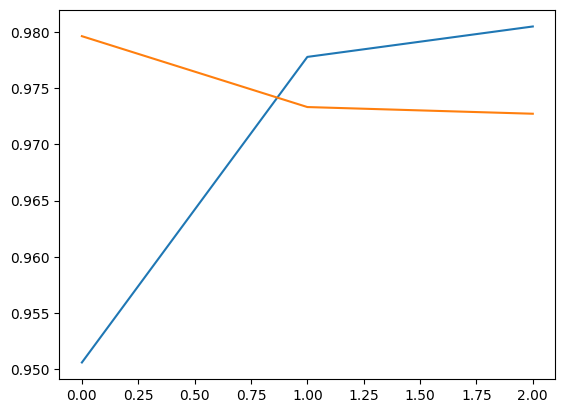

In [84]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()



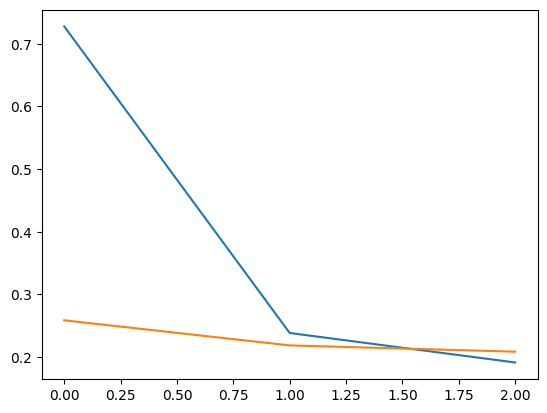

In [85]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

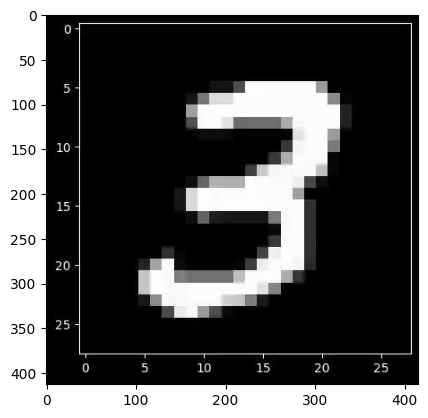

In [148]:
import cv2
import numpy as np
test_img = cv2.imread(r'/content/images.jfif', cv2.IMREAD_GRAYSCALE)   # change path
test_img = 255 - test_img
plt.imshow(test_img, cmap='gray')
plt.show()

In [149]:
test_img = cv2.resize(test_img,(28,28))

In [150]:
test_img = test_img / 255.0

In [151]:
test_input = test_img.reshape(1,28,28,1)

In [152]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[1.0933420e-06, 7.6115644e-04, 1.7360111e-03, 9.9483216e-01,
        1.3598020e-05, 2.7432537e-04, 3.5817011e-06, 1.7559788e-03,
        2.8460709e-04, 3.3742693e-04]], dtype=float32)

In [153]:
def predict_image(test_inputs):
    result = model.predict(test_inputs)
    return np.argmax(result[0])

In [154]:
print(predict_image(test_input))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
3
